# Detecção de Tumores Cerebrais com Inteligência Artificial






## Parte 1 — Preparando o ambiente

In [20]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: []


In [21]:
!pip install -q kaggle scikit-learn seaborn


## Parte 2 — Baixando o dataset

In [22]:
import os
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/dataset --unzip

DATA_DIR  = "/content/dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR  = os.path.join(DATA_DIR, "Testing")
CLASSES   = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASSES)

for nome, pasta in [("Treino", TRAIN_DIR), ("Teste", TEST_DIR)]:
    print(f"\n--- {nome} ---")
    total = 0
    for c in CLASSES:
        n = len(os.listdir(os.path.join(pasta, c)))
        total += n
        print(f"  {c}: {n}")
    print(f"  Total: {total}")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 187MB/s]

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

--- Treino ---
  glioma: 1400
  meningioma: 1400
  notumor: 1400
  pituitary: 1400
  Total: 5600

--- Teste ---
  glioma: 400
  meningioma: 400
  notumor: 400
  pituitary: 400
  Total: 1600


## Parte 3 — Visualizando as imagens e preparando os dados



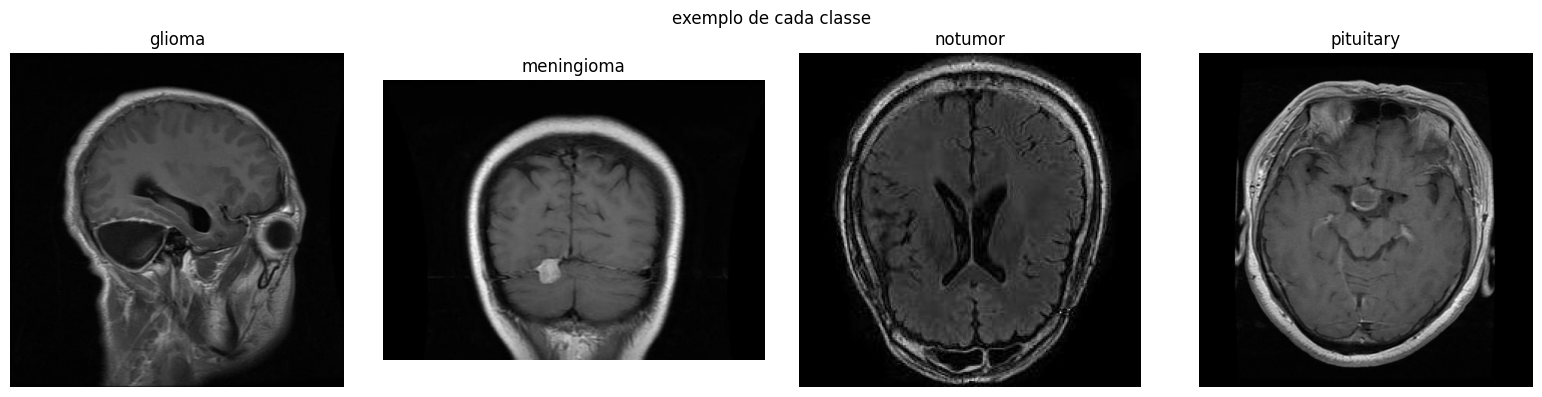

Imagem salva como: exemplo_classes.png


In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axes, CLASSES):
    pasta = os.path.join(TRAIN_DIR, c)
    img = Image.open(os.path.join(pasta, os.listdir(pasta)[0]))
    ax.imshow(img, cmap="gray"); ax.set_title(c); ax.axis("off")
plt.suptitle("exemplo de cada classe"); plt.tight_layout()

nome_arquivo = "exemplo_classes.png"
plt.savefig(nome_arquivo, dpi=300)
plt.show()
print(f"Imagem salva como: {nome_arquivo}")

In [25]:
#Configurações
IMG_SIZE_MLP = 64
IMG_SIZE_TR  = 80
PATCH_SIZE   = 8
BATCH_SIZE   = 32
SEED         = 42
EPOCAS_MLP   = 20
EPOCAS_TR    = 20

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Gerador simples
gen_simples = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Gerador com argumentation
gen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15]
)

gen_teste = ImageDataGenerator(rescale=1./255)

def criar_geradores(img_size, augmentation=False):
    base = gen_aug if augmentation else gen_simples
    treino = base.flow_from_directory(
        TRAIN_DIR, target_size=(img_size, img_size), batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASSES, subset='training', seed=SEED)
    val = base.flow_from_directory(
        TRAIN_DIR, target_size=(img_size, img_size), batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASSES, subset='validation', seed=SEED)
    teste = gen_teste.flow_from_directory(
        TEST_DIR, target_size=(img_size, img_size), batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASSES, shuffle=False)
    return treino, val, teste

print("Geradores prontos.")


Geradores prontos.


## Parte 4 — Função de avaliação - 4 métricas



In [33]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)
import pandas as pd, seaborn as sns, time

tabela = []

def avaliar(modelo, gen_teste, nome, historico=None, tempo=None):
    gen_teste.reset()
    y_real    = gen_teste.classes
    probs     = modelo.predict(gen_teste, verbose=0)
    y_pred    = np.argmax(probs, axis=1)

    ac = accuracy_score(y_real, y_pred)
    pr = precision_score(y_real, y_pred, average='macro', zero_division=0)
    re = recall_score(y_real, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_real, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    print(f"  Acurácia : {ac:.4f}")
    print(f"  Precisão : {pr:.4f}")
    print(f"  Recall   : {re:.4f}")
    print(f"  F1-Score : {f1:.4f}")

    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_real, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Matriz de Confusão\n{nome}")
    plt.ylabel("Real"); plt.xlabel("Previsto")
    plt.tight_layout(); plt.show()

    if historico:
        fig, ax = plt.subplots(1, 2, figsize=(11,4))
        ax[0].plot(historico.history['loss'], label='treino')
        ax[0].plot(historico.history['val_loss'], label='validação')
        ax[0].set_title(f'Loss — {nome}'); ax[0].legend()
        ax[1].plot(historico.history['accuracy'], label='treino')
        ax[1].plot(historico.history['val_accuracy'], label='validação')
        ax[1].set_title(f'Acurácia — {nome}'); ax[1].legend()
        plt.tight_layout(); plt.show()

    tabela.append({"Experimento": nome,
                   "Acurácia": round(ac,4), "Precisão": round(pr,4),
                   "Recall": round(re,4), "F1-Score": round(f1,4)})

print("Função de avaliação pronta.")


Função de avaliação pronta.


## Parte 5 — Grupo 1: MLP

Os 4 experimentos variam:
- Número de camadas e neurônios
- Dropout
- Regularização L2
- BatchNormalization

In [34]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

def criar_mlp(neuronios=256, n_camadas=2, dropout=0.0, l2=0.0, batchnorm=False):
    """
    Monta a MLP. Parâmetros:
      neuronios  = quantos neurônios em cada camada densa
      n_camadas  = quantas camadas densas intermediárias
      dropout    = taxa de dropout (0 = sem dropout)
      l2         = força da regularização L2 (0 = sem L2)
      batchnorm  = se True, adiciona BatchNormalization entre as camadas
    """
    reg = regularizers.l2(l2) if l2 > 0 else None

    modelo = models.Sequential()
    # Achata a imagem: de (64,64,3) vira (12288,)
    modelo.add(layers.Flatten(input_shape=(IMG_SIZE_MLP, IMG_SIZE_MLP, 3)))

    for _ in range(n_camadas):
        modelo.add(layers.Dense(neuronios, activation='relu',
                                 kernel_regularizer=reg))
        if batchnorm:
            modelo.add(layers.BatchNormalization())
        if dropout > 0:
            modelo.add(layers.Dropout(dropout))

    modelo.add(layers.Dense(len(CLASSES), activation='softmax'))
    modelo.compile(optimizer='adam', loss='categorical_crossentropy',
                   metrics=['accuracy'])
    return modelo

print("Função criar_mlp() pronta.")


Função criar_mlp() pronta.


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,212,804 (12.26 MB)

 Trainable params: 3,212,804 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.5877 - loss: 1.0285 - val_accuracy: 0.7214 - val_loss: 0.7482
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7444 - loss: 0.6466 - val_accuracy: 0.7473 - val_loss: 0.6660
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8170 - loss: 0.4993 - val_accuracy: 0.7545 - val_loss: 0.6510
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.8440 - loss: 0.4134 - val_accuracy: 0.7812 - val_loss: 0.5799
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8609 - loss: 0.3745 - val_accuracy: 0.8009 - val_loss: 0.6106
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8717 - loss: 0.3406 - val_accuracy: 0.7866 - val_loss: 0.6297
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8826 - loss: 0.3101 - val_accuracy: 0.8304 - val_loss: 0.5319
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9150 - loss: 0.2234 - val_acc

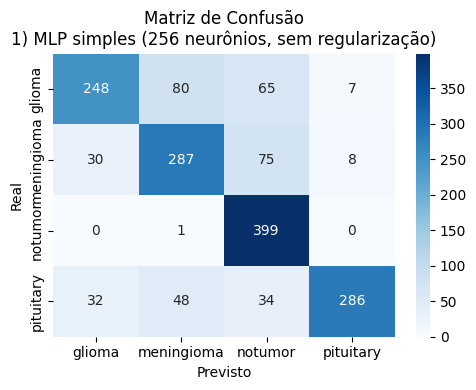

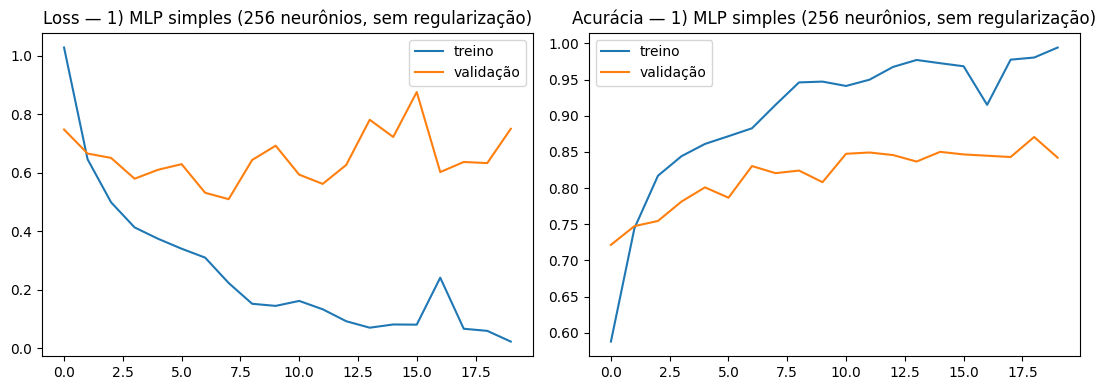

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
# Experimento 1: MLP simples
treino, val, teste = criar_geradores(IMG_SIZE_MLP, augmentation=False)

modelo1 = criar_mlp(neuronios=256, n_camadas=2, dropout=0.0, l2=0.0, batchnorm=False)
modelo1.summary()

t0 = time.time()
hist1 = modelo1.fit(treino, validation_data=val, epochs=EPOCAS_MLP, verbose=1)
t1 = time.time()

avaliar(modelo1, teste, "1) MLP simples (256 neurônios, sem regularização)", hist1)

from google.colab import files
files.download('exemplo_classes.png')


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.4728 - loss: 1.2600 - val_accuracy: 0.6455 - val_loss: 0.9069
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.5259 - loss: 1.0509 - val_accuracy: 0.6705 - val_loss: 0.8794
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.5850 - loss: 0.9162 - val_accuracy: 0.7116 - val_loss: 0.8082
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.5975 - loss: 0.8955 - val_accuracy: 0.7116 - val_loss: 0.7406
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.6295 - loss: 0.8170 - val_accuracy: 0.7348 - val_loss: 0.6728
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.6583 - loss: 0.7666 - val_accuracy: 0.7286 - val_loss: 0.6747
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.6187 - loss: 0.8644 - val_accuracy: 0.6973 - val_loss: 0.7653
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.6292 - loss: 0.8042 - val_accuracy: 0.

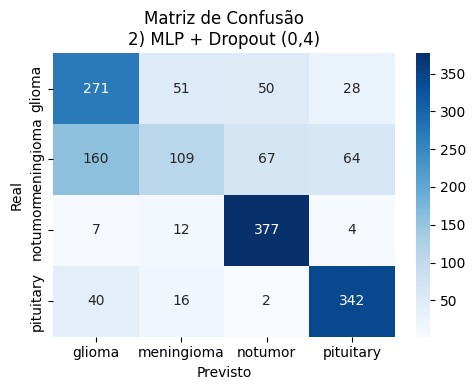

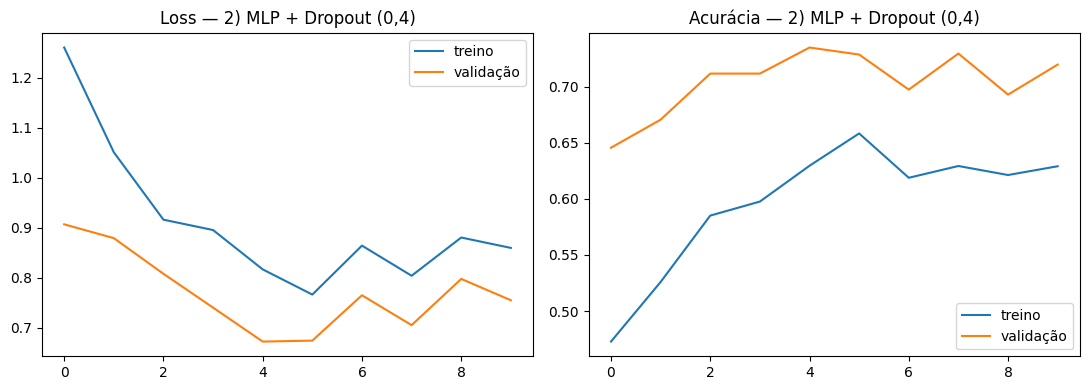

In [36]:
#Experimento 2: MLP + Dropout

treino, val, teste = criar_geradores(IMG_SIZE_MLP, augmentation=False)

modelo2 = criar_mlp(neuronios=256, n_camadas=2, dropout=0.4, l2=0.0, batchnorm=False)

t0 = time.time()
hist2 = modelo2.fit(treino, validation_data=val, epochs=EPOCAS_MLP, verbose=1,
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                              restore_best_weights=True)])
t1 = time.time()

avaliar(modelo2, teste, "2) MLP + Dropout (0,4)", hist2)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4958 - loss: 1.7560 - val_accuracy: 0.6598 - val_loss: 1.2416
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.5882 - loss: 1.2562 - val_accuracy: 0.6411 - val_loss: 1.1038
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.5982 - loss: 1.1245 - val_accuracy: 0.7205 - val_loss: 0.9876
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.6170 - loss: 1.0331 - val_accuracy: 0.7134 - val_loss: 0.8857
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.6208 - loss: 0.9989 - val_accuracy: 0.7045 - val_loss: 0.8535
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.5989 - loss: 0.9921 - val_accuracy: 0.7063 - val_loss: 0.8910
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.6201 - loss: 0.9674 - val_accuracy: 0.6848 - val_loss: 0.8229
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.6288 - loss: 0.9125 - val_accuracy: 0.6

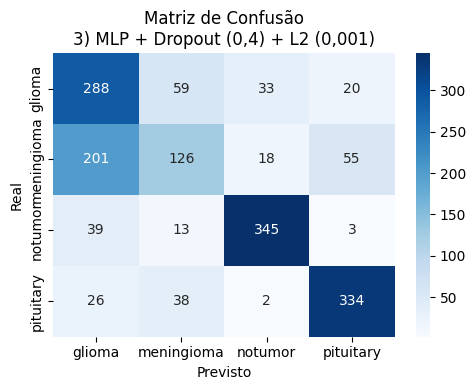

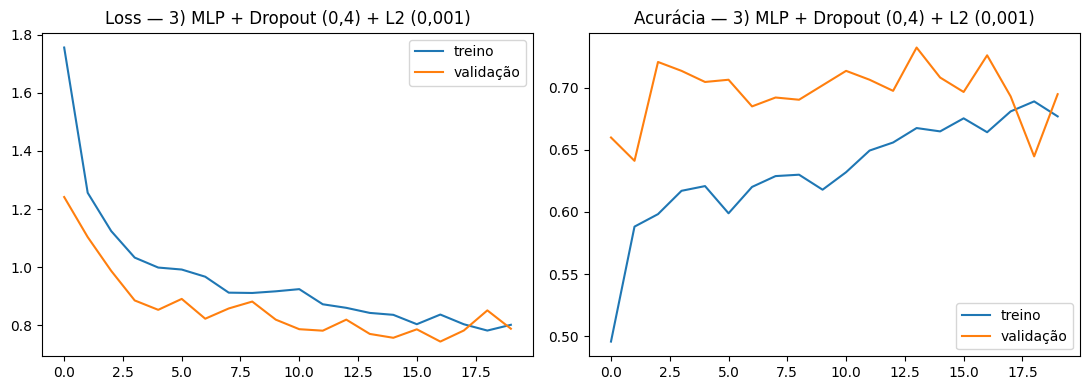

In [37]:
# Experimento 3: MLP + Dropout + L2
treino, val, teste = criar_geradores(IMG_SIZE_MLP, augmentation=False)

modelo3 = criar_mlp(neuronios=256, n_camadas=2, dropout=0.4, l2=0.001, batchnorm=False)

t0 = time.time()
hist3 = modelo3.fit(treino, validation_data=val, epochs=EPOCAS_MLP, verbose=1,
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                              restore_best_weights=True)])
t1 = time.time()

avaliar(modelo3, teste, "3) MLP + Dropout (0,4) + L2 (0,001)", hist3)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.6842 - loss: 0.9439 - val_accuracy: 0.5125 - val_loss: 1.4987
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.7882 - loss: 0.6072 - val_accuracy: 0.7830 - val_loss: 0.5586
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.8188 - loss: 0.5083 - val_accuracy: 0.7536 - val_loss: 0.7101
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8417 - loss: 0.4360 - val_accuracy: 0.6955 - val_loss: 1.0120
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.8522 - loss: 0.3975 - val_accuracy: 0.7009 - val_loss: 1.0924
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8641 - loss: 0.3800 - val_accuracy: 0.6929 - val_loss: 1.1039
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.8739 - loss: 0.3429 - val_accuracy: 0.6268 - val_loss: 1.4946

  4) MLP maior (512 neurônios, 3 camadas) + BatchNorm
  Acurácia : 0.7294
  Precisão : 0.

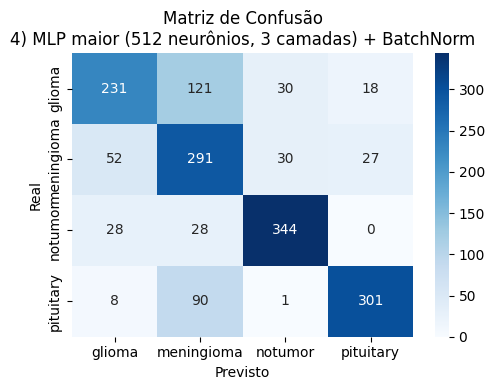

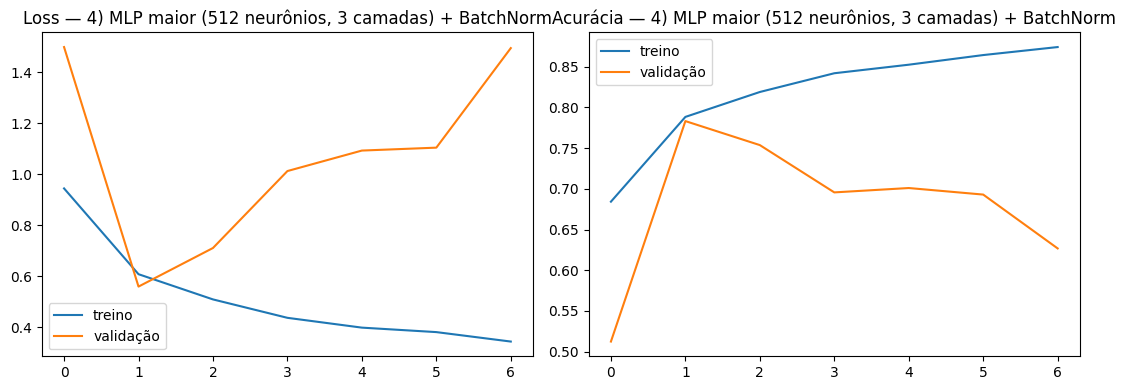

In [38]:
# Experimento 4: MLP maior + BatchNormalization
treino, val, teste = criar_geradores(IMG_SIZE_MLP, augmentation=False)

modelo4 = criar_mlp(neuronios=512, n_camadas=3, dropout=0.3, l2=0.0, batchnorm=True)

t0 = time.time()
hist4 = modelo4.fit(treino, validation_data=val, epochs=EPOCAS_MLP, verbose=1,
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                              restore_best_weights=True)])
t1 = time.time()

avaliar(modelo4, teste, "4) MLP maior (512 neurônios, 3 camadas) + BatchNorm", hist4)


## Parte 6 — Grupo 2: Vision Transformer


In [39]:
import tensorflow as tf
from tensorflow.keras import layers

class PatchEncoder(layers.Layer):
    """
    Corta a imagem em quadradinhos e projeta cada um em um vetor,
    adiciona informaçãoo de posição.
    """
    def __init__(self, patch_size, num_patches, dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size  = patch_size
        self.num_patches = num_patches
        self.proj        = layers.Dense(dim)
        self.pos_embed   = layers.Embedding(input_dim=num_patches, output_dim=dim)

    def call(self, imgs):
        B = tf.shape(imgs)[0]
        patches = tf.image.extract_patches(
            imgs,
            sizes  =[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates  =[1, 1, 1, 1], padding='VALID')
        patches = tf.reshape(patches, [B, -1, patches.shape[-1]])
        pos     = tf.range(0, self.num_patches)
        return self.proj(patches) + self.pos_embed(pos)


def bloco_transformer(x, heads, dim, dropout, l2=0.0):
    """
     compara todos os patches entre si (todos contra todos),
    e depois aplica uma rede densa com regularização L2 opcional.
    """
    reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None

    # multi-cabeça
    x1 = layers.LayerNormalization()(x)
    attn = layers.MultiHeadAttention(
        num_heads=heads, key_dim=dim, dropout=dropout)(x1, x1)
    x2 = layers.Add()([attn, x])

    # Rede densa
    x3 = layers.LayerNormalization()(x2)
    x3 = layers.Dense(dim * 2, activation='gelu', kernel_regularizer=reg)(x3)
    x3 = layers.Dropout(dropout)(x3)
    x3 = layers.Dense(dim, kernel_regularizer=reg)(x3)
    return layers.Add()([x3, x2])


def criar_transformer(n_blocos=2, dim=64, heads=4, dropout=0.1, l2=0.0):
    num_patches = (IMG_SIZE_TR // PATCH_SIZE) ** 2   # ex: (80//8)^2 = 100 patches

    entrada = layers.Input(shape=(IMG_SIZE_TR, IMG_SIZE_TR, 3))
    x = PatchEncoder(PATCH_SIZE, num_patches, dim)(entrada)

    for _ in range(n_blocos):
        x = bloco_transformer(x, heads, dim, dropout, l2)

    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)

    reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None
    x = layers.Dense(128, activation='gelu', kernel_regularizer=reg)(x)
    saida = layers.Dense(len(CLASSES), activation='softmax')(x)

    modelo = tf.keras.Model(entrada, saida)
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy', metrics=['accuracy'])
    return modelo

print("Função criar_transformer() pronta.")
print(f"Cada imagem {IMG_SIZE_TR}×{IMG_SIZE_TR} gera {(IMG_SIZE_TR//PATCH_SIZE)**2} patches de {PATCH_SIZE}×{PATCH_SIZE} pixels.")


Função criar_transformer() pronta.
Cada imagem 80×80 gera 100 patches de 8×8 pixels.


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 80, 80, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 100, 64)   │     18,752 │ input_layer_7[0]… │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 100, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 100, 128)  │          0 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 100, 64)   │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ dense_24[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 100, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 100, 128)  │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 100, 64)   │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 100, 64)   │          0 │ dense_26[0][0],   │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 194,116 (758.27 KB)

 Trainable params: 194,116 (758.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 287ms/step - accuracy: 0.5699 - loss: 0.9901 - val_accuracy: 0.7054 - val_loss: 0.7409
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 272ms/step - accuracy: 0.7746 - loss: 0.6036 - val_accuracy: 0.7830 - val_loss: 0.5886
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 273ms/step - accuracy: 0.8016 - loss: 0.5215 - val_accuracy: 0.7830 - val_loss: 0.5810
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 268ms/step - accuracy: 0.8190 - loss: 0.4821 - val_accuracy: 0.7848 - val_loss: 0.5328
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 262ms/step - accuracy: 0.8424 - loss: 0.4355 - val_accuracy: 0.8054 - val_loss: 0.5128
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 262ms/step - accuracy: 0.8355 - loss: 0.4427 - val_accuracy: 0.8241 - val_loss: 0.5066
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 306ms/step - accuracy: 0.8489 - loss: 0.4139 - val_accuracy: 0.8339 - val_loss: 0.4525
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 259ms/step - accuracy: 0.8589 - loss: 0

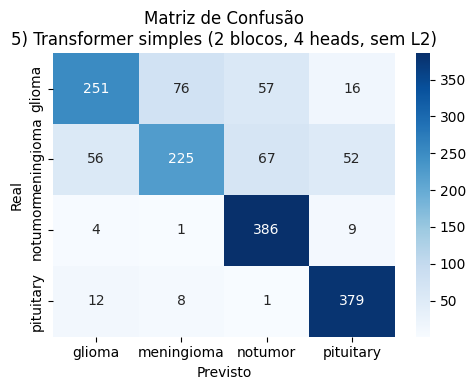

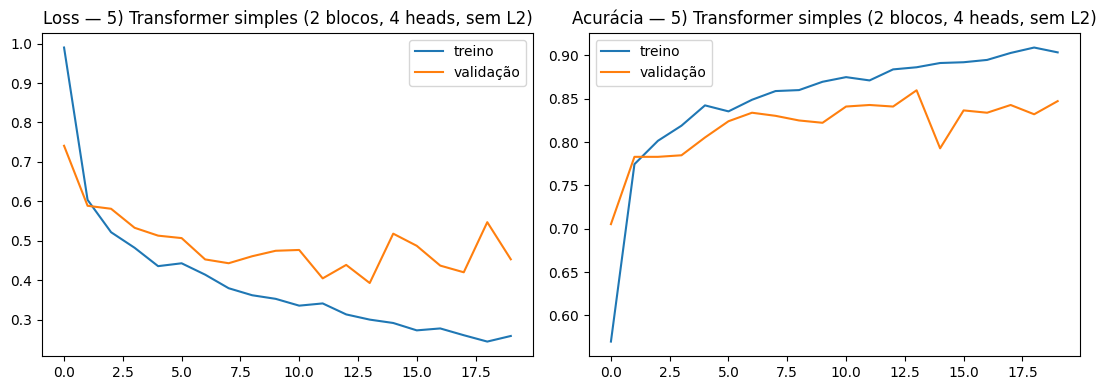

In [40]:
# Experimento 5 Transformer simples
treino_tr, val_tr, teste_tr = criar_geradores(IMG_SIZE_TR, augmentation=False)

modelo5 = criar_transformer(n_blocos=2, dim=64, heads=4, dropout=0.1, l2=0.0)
modelo5.summary()

t0 = time.time()
hist5 = modelo5.fit(treino_tr, validation_data=val_tr, epochs=EPOCAS_TR, verbose=1)
t1 = time.time()

avaliar(modelo5, teste_tr, "5) Transformer simples (2 blocos, 4 heads, sem L2)", hist5)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - accuracy: 0.5554 - loss: 1.4123 - val_accuracy: 0.7000 - val_loss: 1.1711
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.7737 - loss: 0.9408 - val_accuracy: 0.8000 - val_loss: 0.8380
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.8174 - loss: 0.7902 - val_accuracy: 0.7777 - val_loss: 0.8230
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.8444 - loss: 0.6857 - val_accuracy: 0.8027 - val_loss: 0.7232
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8556 - loss: 0.6202 - val_accuracy: 0.8330 - val_loss: 0.6326
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8536 - loss: 0.5760 - val_accuracy: 0.8161 - val_loss: 0.6119
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.8621 - loss: 0.5470 - val_ac

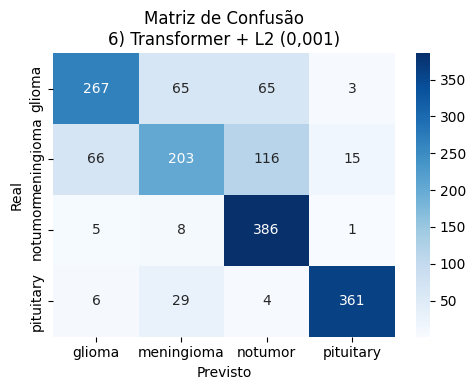

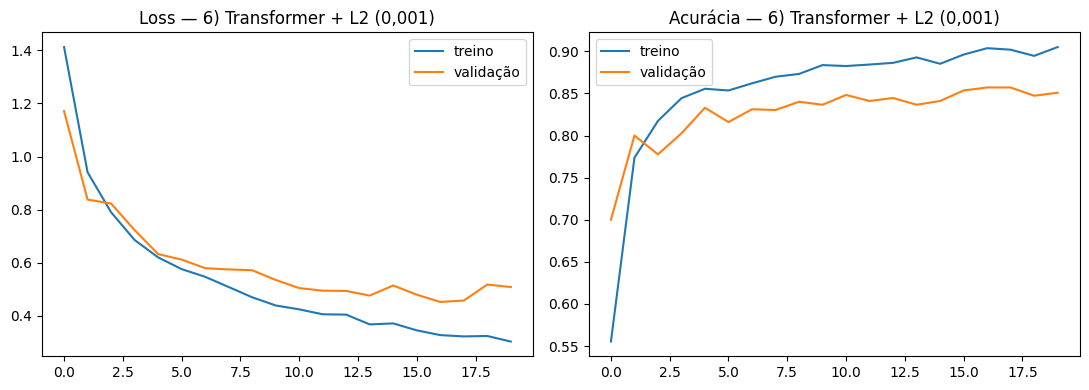

In [ ]:
#experimento 6: Transformer + L2

treino_tr, val_tr, teste_tr = criar_geradores(IMG_SIZE_TR, augmentation=False)

modelo6 = criar_transformer(n_blocos=2, dim=64, heads=4, dropout=0.1, l2=0.001)

t0 = time.time()
hist6 = modelo6.fit(treino_tr, validation_data=val_tr, epochs=EPOCAS_TR, verbose=1,
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                              restore_best_weights=True)])
t1 = time.time()

avaliar(modelo6, teste_tr, "6) Transformer + L2 (0,001)", hist6)


Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 164ms/step - accuracy: 0.5188 - loss: 1.5102 - val_accuracy: 0.5759 - val_loss: 1.3333
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.6277 - loss: 1.2530 - val_accuracy: 0.5973 - val_loss: 1.2548
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.6475 - loss: 1.1585 - val_accuracy: 0.6107 - val_loss: 1.2100
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.6504 - loss: 1.1127 - val_accuracy: 0.5848 - val_loss: 1.1962
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.6665 - loss: 1.0461 - val_accuracy: 0.6429 - val_loss: 1.0479
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - accuracy: 0.6721 - loss: 1.0067 - val_accuracy: 0.6464 - val_loss: 1.0342
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.6839 - loss: 0.9481

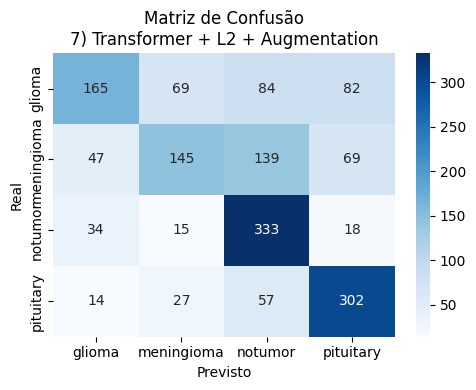

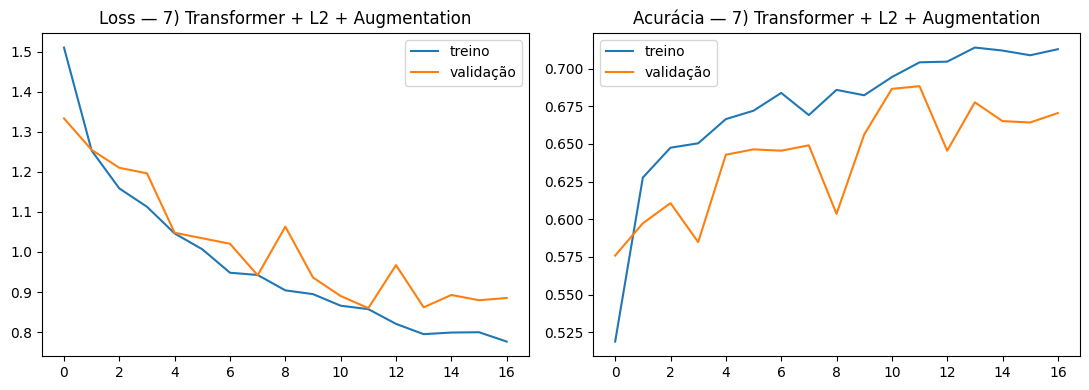

In [ ]:
# Experimento 7: Transformer + L2 + Data Augmentation

treino_tr_aug, val_tr_aug, teste_tr_aug = criar_geradores(IMG_SIZE_TR, augmentation=True)

modelo7 = criar_transformer(n_blocos=2, dim=64, heads=4, dropout=0.1, l2=0.001)

t0 = time.time()
hist7 = modelo7.fit(treino_tr_aug, validation_data=val_tr_aug, epochs=EPOCAS_TR,
                     verbose=1,
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                              restore_best_weights=True)])
t1 = time.time()

avaliar(modelo7, teste_tr_aug, "7) Transformer + L2 + Augmentation", hist7)


Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 48s 170ms/step - accuracy: 0.4500 - loss: 2.1264 - val_accuracy: 0.5089 - val_loss: 1.8146
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - accuracy: 0.5808 - loss: 1.5944 - val_accuracy: 0.4973 - val_loss: 1.5550
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.5980 - loss: 1.3596 - val_accuracy: 0.6339 - val_loss: 1.2366
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step - accuracy: 0.6484 - loss: 1.1520 - val_accuracy: 0.5768 - val_loss: 1.1950
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 157ms/step - accuracy: 0.6536 - loss: 1.0780 - val_accuracy: 0.6000 - val_loss: 1.1920
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.6596 - loss: 1.0186 - val_accuracy: 0.6277 - val_loss: 1.0093
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.6516 - loss: 0.9825 - val_accuracy: 0.6313 - val_loss: 1.0313
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 155ms/step - accuracy: 0.6701 - loss: 0

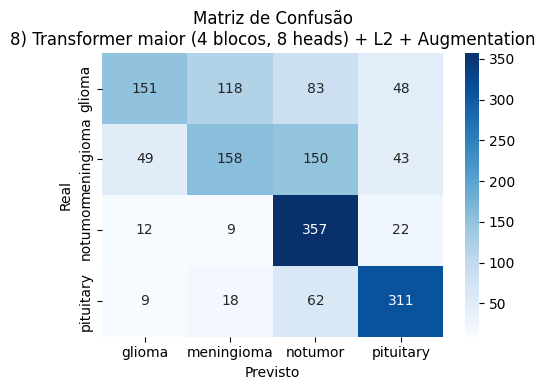

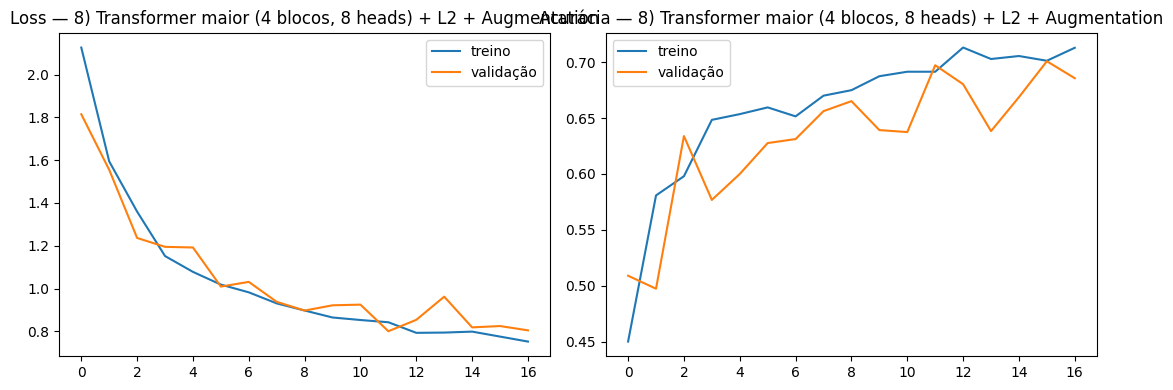

In [ ]:
# Experimento 8: Transformer maior + L2
modelo8 = criar_transformer(n_blocos=4, dim=96, heads=8, dropout=0.2, l2=0.001)

t0 = time.time()
hist8 = modelo8.fit(treino_tr_aug, validation_data=val_tr_aug, epochs=EPOCAS_TR,
                     verbose=1,
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                              restore_best_weights=True)])
t1 = time.time()

avaliar(modelo8, teste_tr_aug,
        "8) Transformer maior (4 blocos, 8 heads) + L2 + Augmentation", hist8)


## Parte 7 — Tabela comparativa dos 8 experimentos

In [ ]:
df = pd.DataFrame(tabela)
df = df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
print(df.to_string(index=False))
df


                                                 Experimento  Acurácia  Precisão  Recall  F1-Score
           1) MLP simples (256 neurônios, sem regularização)    0.8169    0.8233  0.8169    0.8127
           1) MLP simples (256 neurônios, sem regularização)    0.8044    0.8074  0.8044    0.8021
          5) Transformer simples (2 blocos, 4 heads, sem L2)    0.7919    0.7946  0.7919    0.7843
                                 6) Transformer + L2 (0,001)    0.7606    0.7669  0.7606    0.7536
                                      2) MLP + Dropout (0,4)    0.7131    0.7183  0.7131    0.6988
                                      2) MLP + Dropout (0,4)    0.6950    0.6925  0.6950    0.6645
         4) MLP maior (512 neurônios, 3 camadas) + BatchNorm    0.6637    0.6810  0.6638    0.6554
                         3) MLP + Dropout (0,4) + L2 (0,001)    0.6575    0.6592  0.6575    0.6255
8) Transformer maior (4 blocos, 8 heads) + L2 + Augmentation    0.6106    0.6214  0.6106    0.5923
          

,Experimento,Acurácia,Precisão,Recall,F1-Score
0,"1) MLP simples (256 neurônios, sem regularização)",0.8169,0.8233,0.8169,0.8127
1,"1) MLP simples (256 neurônios, sem regularização)",0.8044,0.8074,0.8044,0.8021
2,"5) Transformer simples (2 blocos, 4 heads, sem...",0.7919,0.7946,0.7919,0.7843
3,"6) Transformer + L2 (0,001)",0.7606,0.7669,0.7606,0.7536
4,"2) MLP + Dropout (0,4)",0.7131,0.7183,0.7131,0.6988
5,"2) MLP + Dropout (0,4)",0.6950,0.6925,0.6950,0.6645
6,"4) MLP maior (512 neurônios, 3 camadas) + Batc...",0.6637,0.6810,0.6638,0.6554
7,"3) MLP + Dropout (0,4) + L2 (0,001)",0.6575,0.6592,0.6575,0.6255
8,"8) Transformer maior (4 blocos, 8 heads) + L2 ...",0.6106,0.6214,0.6106,0.5923
9,7) Transformer + L2 + Augmentation,0.5906,0.5964,0.5906,0.5732
